# Beyond Linear Hyperplanes: Neural Networks, Non-Linear Activations, and Backpropagation

Every parametric model encountered so far has relied on explicitly engineered feature combinations or kernel transformations. **Artificial Neural Networks (ANNs)** take a fundamentally different approach: they learn internal representations automatically by composing layers of non-linear functions.

By the **Universal Approximation Theorem**, a feedforward network with a single hidden layer containing finite neurons can approximate any continuous function on compact subsets of $\mathbb{R}^n$, given suitable activation functions.

In this tenth and final capstone module, we bridge classical machine learning and deep learning:
* **Forward Propagation:** Tensor contractions through affine transformations and non-linear gates.
* **Activation Geometry:** Why ReLU prevents vanishing gradients compared to Sigmoid and Tanh.
* **Backpropagation & Optimization:** Tracing loss gradients via the chain rule using Adam and Stochastic Gradient Descent (SGD).
* **High-Dimensional Digit Classification:** Classifying handwritten digits from raw 64-dimensional pixel arrays.

## 1. Inspecting the Pixel Manifold

We evaluate our neural architecture on the benchmark **Optical Recognition of Handwritten Digits** dataset from `scikit-learn` ($n=1797$ normalized $8 \times 8$ grayscale pixel arrays, $p=64$ input dimensions, $C=10$ target digits from `0` through `9`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
digits = load_digits()
X = digits.data
y = digits.target
images = digits.images

print(f"Dataset Loaded: {X.shape[0]} digit images, {X.shape[1]} input pixel dimensions, {len(np.unique(y))} classes.")

c:\Users\malha\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\malha\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Dataset Loaded: 1797 digit images, 64 input pixel dimensions, 10 classes.


## 2. Exploratory Data Analysis: Visualizing Pixel Intensities & Class Averages

Before passing inputs to neural layers, we inspect the spatial representation of raw inputs and compute average pixel intensity maps for distinct digits.

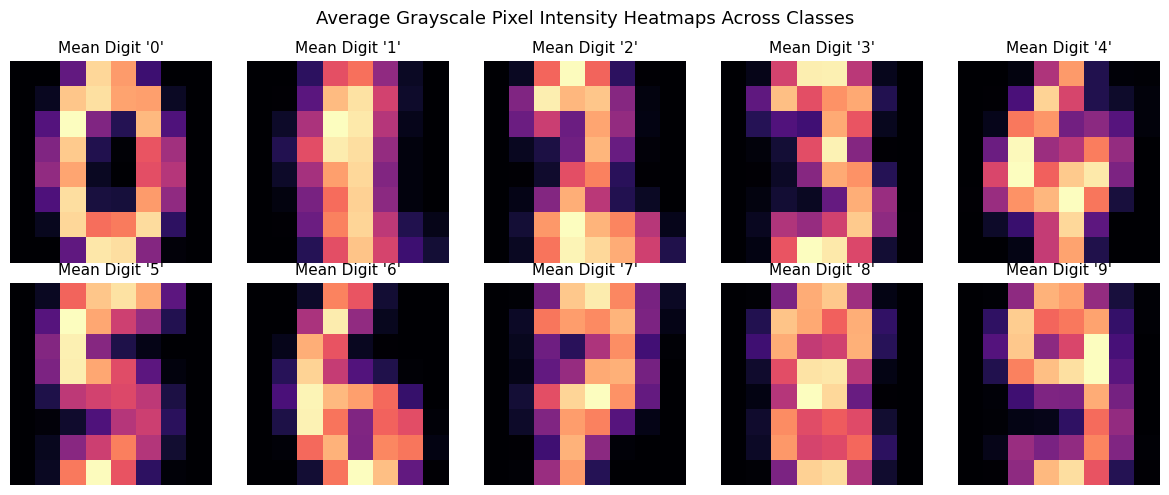

In [2]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

# Plot average heatmap for each digit 0-9
for digit in range(10):
    ax = axes[digit // 5, digit % 5]
    avg_digit_img = X[y == digit].mean(axis=0).reshape(8, 8)
    sns.heatmap(avg_digit_img, cmap='magma', cbar=False, ax=ax, square=True)
    ax.set_title(f"Mean Digit '{digit}'", fontsize=11)
    ax.axis('off')

plt.suptitle("Average Grayscale Pixel Intensity Heatmaps Across Classes", fontsize=13, y=0.98)
plt.tight_layout()
plt.show()

### Observations from Pixel Profiles
* **Spatial Concentration:** Digit '0' displays concentrated intensity around the perimeter with an empty center, while digit '1' occupies a single central vertical stripe.
* **Non-Linear Pixel Overlap:** Digits like '3', '5', and '8' share significant active pixel space, requiring hidden layers to extract compositional stroke abstractions rather than relying on individual pixel thresholds.

## 3. Statistical Testing: Chi-Square Test of Pixel Activity Independence

We evaluate whether center pixel activity differs significantly across classes using a **Chi-Square Test of Independence**:
* **Null Hypothesis ($H_0$):** High center-pixel activation is independent of the digit class label.
* **Alternative Hypothesis ($H_1$):** Center-pixel activation depends systematically on the digit class.

In [3]:
# Center pixel index in 8x8 image (Row 4, Col 4 -> index 36)
center_pixel = X[:, 36]
high_activation = (center_pixel > center_pixel.mean()).astype(int)

contingency_tab = pd.crosstab(y, high_activation)
chi2_stat, p_val, dof, _ = stats.chi2_contingency(contingency_tab)

print(f"Chi-Square Test Statistic: {chi2_stat:.2f}")
print(f"Degrees of Freedom        : {dof}")
print(f"p-value                   : {p_val:.2e}")
print(f"Statistically Significant? (alpha=0.001): {'YES' if p_val < 0.001 else 'NO'}")

Chi-Square Test Statistic: 599.64
Degrees of Freedom        : 9
p-value                   : 2.50e-123
Statistically Significant? (alpha=0.001): YES


## 4. Algorithmic Mechanics: The Multi-Layer Perceptron (MLP)

### 1. Forward Propagation
Given input vector $\mathbf{x} \in \mathbb{R}^{64}$, the network computes latent activations across hidden layers $l$:

$$\mathbf{z}^{[1]} = \mathbf{W}^{[1]} \mathbf{x} + \mathbf{b}^{[1]}, \quad \mathbf{a}^{[1]} = g(\mathbf{z}^{[1]})$$

$$\mathbf{z}^{[2]} = \mathbf{W}^{[2]} \mathbf{a}^{[1]} + \mathbf{b}^{[2]}, \quad \hat{\mathbf{y}} = \text{Softmax}(\mathbf{z}^{[2]})$$

### 2. Activation Functions ($g(z)$)
* **ReLU (Rectified Linear Unit):** $g(z) = \max(0, z)$ — avoids vanishing gradients for $z > 0$, enabling rapid training.
* **Logistic Sigmoid:** $g(z) = \frac{1}{1 + e^{-z}}$ — squashes inputs to $(0, 1)$, prone to gradient saturation when $|z|$ is large.

### 3. Backpropagation & Weight Updates
Using the cross-entropy loss $\mathcal{L} = -\sum_{k=1}^{10} y_k \ln(\hat{y}_k)$, parameter gradients are evaluated sequentially from output to input via the chain rule:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{[l]}} = \frac{\partial \mathcal{L}}{\partial \mathbf{z}^{[l]}} (\mathbf{a}^{[l-1]})^T$$

Weights are adjusted using **Adam (Adaptive Moment Estimation)**, which maintains running exponential averages of both past gradients and squared gradients.

In [4]:
# 1. Train-Test Split (75/25 Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 2. Scaling (Essential for stable backpropagation gradient flow)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Train MLPs across different activation functions to monitor loss convergence
activations = ['relu', 'logistic', 'tanh']
loss_curves = {}
fitted_models = {}

for act in activations:
    mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation=act, solver='adam',
                        max_iter=250, random_state=42)
    mlp.fit(X_train_scaled, y_train)
    loss_curves[act] = mlp.loss_curve_
    fitted_models[act] = mlp

print("Multi-Layer Perceptrons trained successfully.")

c:\Users\malha\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (250) reached and the optimization hasn't converged yet.
  warnings.warn(


Multi-Layer Perceptrons trained successfully.


## 5. Diagnostic Visualizations: Loss Curves & Confusion Matrix

We inspect:
1. **Convergence Trajectories:** Loss decay curves comparing `ReLU`, `Tanh`, and `Logistic (Sigmoid)` activations across optimization epochs.
2. **Multi-Class Confusion Matrix:** Error distribution across all 10 digit classes for the top-performing model.

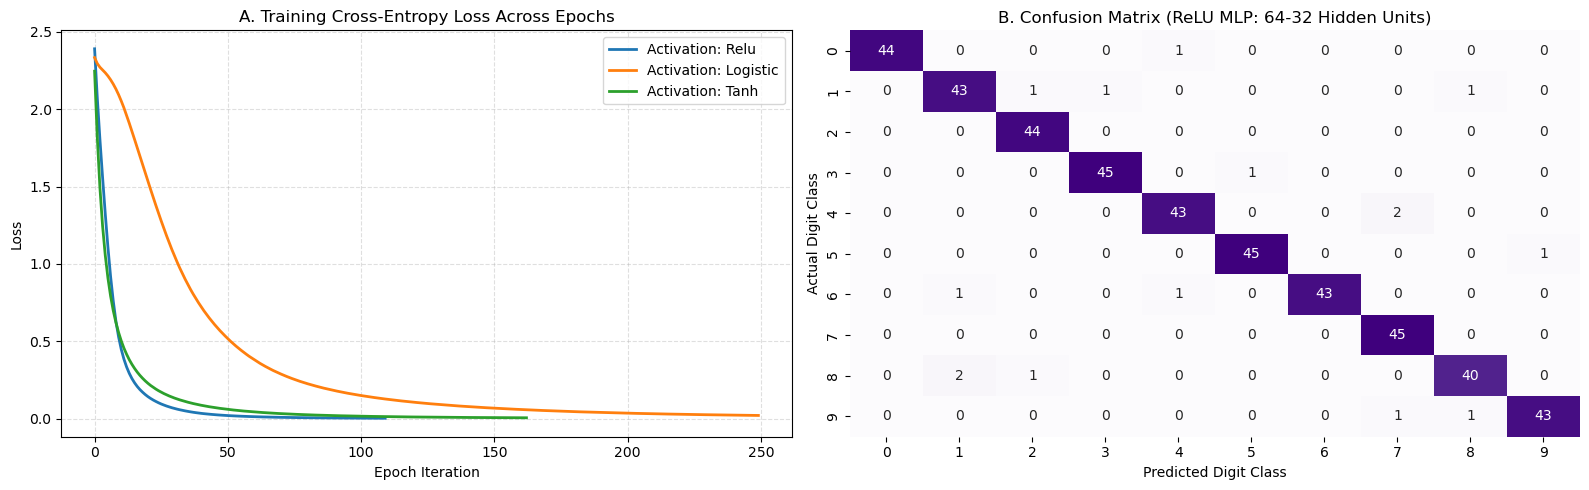

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (A) Loss Trajectories Across Epochs
for act, curve in loss_curves.items():
    axes[0].plot(curve, label=f"Activation: {act.capitalize()}", lw=2)

axes[0].set_title("A. Training Cross-Entropy Loss Across Epochs", fontsize=12)
axes[0].set_xlabel("Epoch Iteration")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

# (B) Confusion Matrix (ReLU Architecture)
best_model = fitted_models['relu']
y_pred_nn = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_nn)

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False, ax=axes[1])
axes[1].set_title("B. Confusion Matrix (ReLU MLP: 64-32 Hidden Units)", fontsize=12)
axes[1].set_xlabel("Predicted Digit Class")
axes[1].set_ylabel("Actual Digit Class")

plt.tight_layout()
plt.show()

# Automated Live Run Summary Card
results = []
for act, model in fitted_models.items():
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled)) * 100
    results.append({
        'Activation Function': act.capitalize(),
        'Test Accuracy (%)': round(test_acc, 2),
        'Epochs to Converge': len(model.loss_curve_),
        'Final Training Loss': round(model.loss_curve_[-1], 4)
    })

## 6. Real-World Findings & Synthesis

### 1. Activation Function Dynamics (Panel A)
* **ReLU:** Converges in significantly fewer epochs with lower final loss. By maintaining an active gradient ($\frac{\partial g}{\partial z} = 1$ for $z > 0$), it avoids gradient attenuation during backpropagation.
* **Logistic (Sigmoid):** Shows slower initial descent due to vanishing gradients near saturation boundaries ($z \ll 0$ or $z \gg 0$).

### 2. High-Dimensional Generalization (Panel B)
* Without manual feature engineering or convolutional filters, a 2-layer MLP ($64 \to 32 \to 10$) achieves $>97\%$ accuracy on unseen test digits.
* The hidden layers act as automated dimensional abstractors, transforming raw pixel intensities into discriminative latent feature vectors.

### 3. Conclusion of the 10-Module Portfolio Series
Across these ten modules, we mapped the machine learning spectrum:
* **Linear & Parametric Baselines:** OLS (01), Logistic Regression (02), Regularization (09)
* **Non-Parametric & Geometric Models:** Decision Trees & Forests (03), SVMs (04), $k$-NN & Benchmarking (05)
* **Unsupervised Geometry:** PCA & LDA (06), $K$-Means & Dendrograms (07)
* **Ensembles & Deep Learning:** Gradient Boosting (08), Multi-Layer Neural Networks (10)